# A = 23 vs. A = 24

Why do we consider $A = 23$ and Urca pair, but discuss $A = 24$ as an electron-capture chain?

Let's load our model again and look at the rates involved in $A = 23$ and $A = 24$

## Load the lab 1 final model

In [1]:
import mesa_reader as mr
import pynucastro as pyna

In [2]:
model = mr.MesaData("lab1/profile2.data")

In [3]:
from pynucastro import mesa_utils

In [4]:
r = 10.0**model.logR
m = model.mass
mesa_zones = mesa_utils.get_all_data(model)

## Look at A = 23 rates

We'll use the rates from the Suzuki library

In [5]:
sl = pyna.SuzukiLibrary()

Below a certain temperature the Suzuki does not provide rate data, so we'll just zero out the rates.  This helper function handles this for us.

In [6]:
def eval_rate(r, rho, T, comp):
    try:
        lambda_r = r.eval(T, rho=rho, comp=comp)
    except ValueError:
        lambda_r = 0.0
    return lambda_r

Get the A = 23 electron-capture and beta-decay rates and evaluate them over the entire model.  Specifically,
we are looking at:

$${}^{23}\mathrm{Na}(e^-,\nu_e){}^{23}\mathrm{Ne}$$

and

$${}^{23}\mathrm{Ne}(,e^-\nu_e){}^{23}\mathrm{Na}$$

In [7]:
rna23ec = sl.get_rate_by_name("na23(,)ne23")
lambda_rna23ec = [eval_rate(rna23ec, rho, T, comp) for rho, T, comp in mesa_zones.values()]

rne23beta = sl.get_rate_by_name("ne23(,)na23")
lambda_rne23beta = [eval_rate(rne23beta, rho, T, comp) for rho, T, comp in mesa_zones.values()]

Now let's plot them.

In [8]:
import matplotlib.pyplot as plt

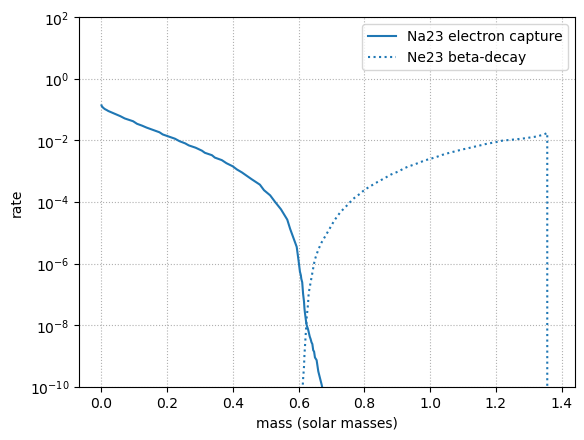

In [9]:
fig, ax = plt.subplots()

ax.semilogy(m, lambda_rna23ec, label="Na23 electron capture", color="C0")
ax.semilogy(m, lambda_rne23beta, label="Ne23 beta-decay", color="C0", ls=":")

ax.set_xlabel("mass (solar masses)")
ax.set_ylabel("rate")
ax.set_ylim(1.e-10, 1.e2)
ax.grid(ls=":")
ax.legend()

We see that the rates intersect about halfway through the star---this is the Urca shell.

## A = 24

Now let's look at the $A = 24$ rates.  We specifically model:

$${}^{24}\mathrm{Mg}(e^-,\nu_e){}^{24}\mathrm{Na}(e^-,\nu_e){}^{24}\mathrm{Ne}$$

and

$${}^{24}\mathrm{Ne}(,e^-\nu_e){}^{24}\mathrm{Na}(,e^-\nu_e){}^{24}\mathrm{Mg}$$

In [10]:
rmg24ec = sl.get_rate_by_name("mg24(,)na24")
lambda_rmg24ec = [eval_rate(rmg24ec, rho, T, comp) for rho, T, comp in mesa_zones.values()]

rna24beta = sl.get_rate_by_name("na24(,)mg24")
lambda_rna24beta = [eval_rate(rna24beta, rho, T, comp) for rho, T, comp in mesa_zones.values()]

In [11]:
rna24ec = sl.get_rate_by_name("na24(,)ne24")
lambda_rna24ec = [eval_rate(rna24ec, rho, T, comp) for rho, T, comp in mesa_zones.values()]

rne24beta = sl.get_rate_by_name("ne24(,)na24")
lambda_rne24beta = [eval_rate(rne24beta, rho, T, comp) for rho, T, comp in mesa_zones.values()]

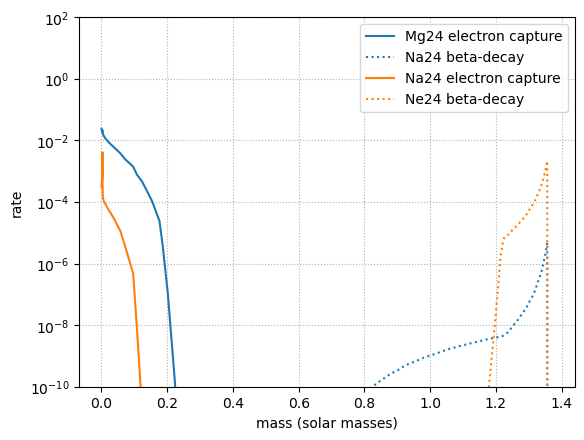

In [12]:
fig, ax = plt.subplots()

ax.semilogy(m, lambda_rmg24ec, label="Mg24 electron capture", color="C0")
ax.semilogy(m, lambda_rna24beta, label="Na24 beta-decay", color="C0", ls=":")

ax.semilogy(m, lambda_rna24ec, label="Na24 electron capture", color="C1")
ax.semilogy(m, lambda_rne24beta, label="Ne24 beta-decay", color="C1", ls=":")

ax.set_xlabel("mass (solar masses)")
ax.set_ylabel("rate")
ax.set_ylim(1.e-10, 1.e2)
ax.grid(ls=":")
ax.legend()

Here we see that the electron-capture and beta-decay rates are well-separated.